In [1]:
"""
Take-picture mode: latent vs applied capture reward.

Motivation: real OBC memory / downlink limits (~10 HQ images per orbit).

Production:
  SATELLITE.MAX_PRIMARY_CAPTURES_PER_ORBIT = 10
  simulation/take_picture.py — episode capture budget
  autonomous_control/reward.py — latent_capture_reward / applied_capture_reward

Reward semantics:
  latent  = k * coverage * quality * (1 - cloud_frac)
            coverage = primary obs-line target pixels / total bins
            (hypothetical credit if the agent shuttered now)
  applied = latent only on budgeted shutter for a **novel** target index (T0, T1, …)
  repeat capture of same target → shutter may fire but applied reward = 0

Verification (clouds off, seed=0):
  A/B — fast polar pass (-3..+3 deg): nadir vs target track, single shutter at overpass
  C — wide overflight (-12..+12 deg): OBC target track, 20 take-picture cmds (budget 10)

Export proof MP4s:
  artifacts/06-take-picture-nadir-hold.mp4
  artifacts/06-take-picture-target-track.mp4
  artifacts/06-take-picture-scenario-c-budget.mp4
"""

'\nTake-picture mode: latent vs applied capture reward.\n\nMotivation: real OBC memory / downlink limits (~10 HQ images per orbit).\n\nProduction:\n  SATELLITE.MAX_PRIMARY_CAPTURES_PER_ORBIT = 10\n  simulation/take_picture.py — episode capture budget\n  autonomous_control/reward.py — latent_capture_reward / applied_capture_reward\n\nReward semantics:\n  latent  = k * coverage * quality * (1 - cloud_frac)\n            coverage = primary obs-line target pixels / total bins\n            (hypothetical credit if the agent shuttered now)\n  applied = latent only on budgeted shutter for a **novel** target index (T0, T1, …)\n  repeat capture of same target → shutter may fire but applied reward = 0\n\nVerification (clouds off, seed=0):\n  A/B — fast polar pass (-3..+3 deg): nadir vs target track, single shutter at overpass\n  C — wide overflight (-12..+12 deg): OBC target track, 20 take-picture cmds (budget 10)\n\nExport proof MP4s:\n  artifacts/06-take-picture-nadir-hold.mp4\n  artifacts/06-ta

In [2]:
import os
import sys
from pathlib import Path

notebook_dir = Path.cwd()
backend_root = notebook_dir
for _ in range(6):
    if (backend_root / "simulation").is_dir():
        break
    backend_root = backend_root.parent
os.chdir(backend_root)
sys.path.insert(0, str(backend_root))
_s01_dir = backend_root / "notebooks" / "s01"
sys.path.insert(0, str(_s01_dir))
print(f"backend_root={backend_root}")

backend_root=c:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend


In [3]:
import importlib

import autonomous_control.reward as _reward
import simulation.take_picture as _tp
import s01_utils.take_picture_verification as tpv

importlib.reload(_reward)
importlib.reload(_tp)
importlib.reload(tpv)

ctx = tpv.print_take_picture_reward_gate(seed=0)
print()
tpv.print_budget_exhaustion_demo(seed=0)

c:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\simulation\stepper.py:169: UserWarning: controller_update_interval (1 s) is not an integer multiple of simulation_timestep (0.4 s); using nearest multiple: 0.8 s (2 sim steps).
  self._controller_interval_steps, self._effective_controller_interval_s = resolve_controller_interval_steps(


Take-picture capture gate [A: OBC nadir hold]
  budget=10  k_capture=100  latent = k * coverage * quality * (1 - cloud_frac)  (applied only on novel target shutter)

  cmd  cap  taken  novel  tgt  cov    quality  cloud   latent  applied  budget_left
  110  110  yes     yes      T0  0.160   0.3008  0.000     4.81     4.81    9

  captures=1  total_capture_reward=4.81  mean_quality=0.3008

Take-picture capture gate [B: OBC target track]
  budget=10  k_capture=100  latent = k * coverage * quality * (1 - cloud_frac)  (applied only on novel target shutter)

  cmd  cap  taken  novel  tgt  cov    quality  cloud   latent  applied  budget_left
  110  110  yes     yes      T0  1.000   0.9208  0.000    92.08    92.08    9

  captures=1  total_capture_reward=92.08  mean_quality=0.9208

Scenario comparison: nadir capture reward total=4.81  target capture reward total=92.08  (expect target > nadir at overpass)
Capture at step 110  t=43.9 s  (clouds off; stripe visible on both rollouts)
Latent at shu

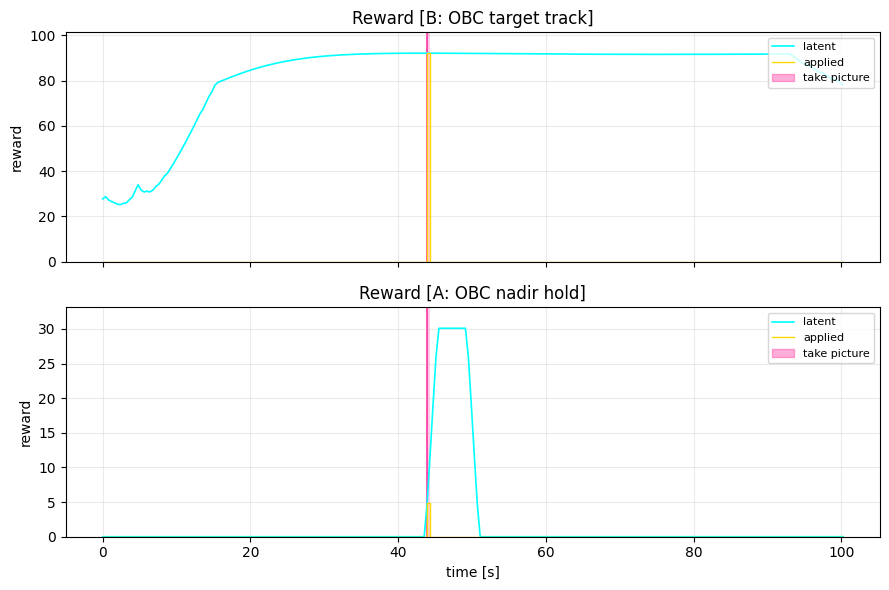

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
tpv.plot_capture_reward_timeline(
    ctx.target_series,
    cmd_steps=ctx.cmd_steps,
    label="B: OBC target track",
    ax=axes[0],
)
tpv.plot_capture_reward_timeline(
    ctx.nadir_series,
    cmd_steps=ctx.cmd_steps,
    label="A: OBC nadir hold",
    ax=axes[1],
)
axes[0].set_xlabel("")
plt.tight_layout()
plt.show()

In [5]:
import matplotlib

matplotlib.use("Agg")

ARTIFACT_DIR = backend_root / "notebooks" / "s01" / "artifacts"
tpv.export_take_picture_verification_videos(ctx, ARTIFACT_DIR)

Exporting 06-take-picture-nadir-hold.mp4 [A nadir hold]  capture step=110  t=43.9s
[video] archived previous export -> C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\video_archive\007-06-take-picture-nadir-hold.mp4


Writing video: 100%|██████████| 113/113 [00:33<00:00,  3.34frame/s]


[mpo_video:after_export] 06-take-picture-nadir-hold.mp4 (199355 bytes, codec=h264)
[mpo_video:play] 06-take-picture-nadir-hold.mp4 (199355 bytes, codec=h264)


artifact=C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\06-take-picture-nadir-hold.mp4
Exporting 06-take-picture-target-track.mp4 [B target track]  capture step=110  t=43.9s
[video] archived previous export -> C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\video_archive\007-06-take-picture-target-track.mp4


Writing video: 100%|██████████| 113/113 [00:30<00:00,  3.74frame/s]


[mpo_video:after_export] 06-take-picture-target-track.mp4 (228214 bytes, codec=h264)
[mpo_video:play] 06-take-picture-target-track.mp4 (228214 bytes, codec=h264)


artifact=C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\06-take-picture-target-track.mp4


{'06-take-picture-nadir-hold.mp4': WindowsPath('C:/Users/cedri/code/autonomous-satellite-control-eth-sem-proj/backend/notebooks/s01/artifacts/06-take-picture-nadir-hold.mp4'),
 '06-take-picture-target-track.mp4': WindowsPath('C:/Users/cedri/code/autonomous-satellite-control-eth-sem-proj/backend/notebooks/s01/artifacts/06-take-picture-target-track.mp4')}

In [6]:
# Scenario C: wide overflight, OBC target track, 11 shutter commands (budget = 10)
ctx_c = tpv.print_scenario_c_budget_gate(seed=0)

Scenario C: OBC target track  orbit=[-12, 12] deg  commands=20  budget=10
Take-picture capture gate [C: wide overflight / budget+1 commands]
  budget=10  k_capture=100  latent = k * coverage * quality * (1 - cloud_frac)  (applied only on novel target shutter)

  cmd  cap  taken  novel  tgt  cov    quality  cloud   latent  applied  budget_left
    0    0  yes     yes      T0  0.230   0.1746  0.000     4.01     4.01    9
   53   53  yes      no      T0  0.190   0.7676  0.000    14.59     0.00    8
  106  106  yes      no      T0  0.240   0.8952  0.000    21.48     0.00    7
  158  158  yes      no      T0  0.270   0.9140  0.000    24.68     0.00    6
  211  211  yes      no      T0  0.330   0.9249  0.000    30.52     0.00    5
  264  264  yes      no      T0  0.440   0.9324  0.000    41.03     0.00    4
  317  317  yes      no      T0  0.620   0.9369  0.000    58.09     0.00    3
  370  370  yes      no      T0  0.930   0.9376  0.000    87.20     0.00    2
  422  422  yes      no      T0

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
tpv.plot_capture_reward_timeline(
    ctx_c.series,
    cmd_steps=ctx_c.cmd_steps,
    label="C: wide target track / 11 cmds",
    ax=ax,
)
plt.tight_layout()
plt.show()

C:\Users\cedri\AppData\Local\Temp\ipykernel_32468\1198653623.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [9]:
tpv.export_scenario_c_video(ctx_c, ARTIFACT_DIR)

Exporting 06-take-picture-scenario-c-budget.mp4 [C wide target track]  commands=20  n_frames=1004
[video] archived previous export -> C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\video_archive\003-06-take-picture-scenario-c-budget.mp4


Writing video: 100%|██████████| 447/447 [02:08<00:00,  3.48frame/s]


[mpo_video:after_export] 06-take-picture-scenario-c-budget.mp4 (787860 bytes, codec=h264)
[mpo_video:play] 06-take-picture-scenario-c-budget.mp4 (787860 bytes, codec=h264)


artifact=C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\notebooks\s01\artifacts\06-take-picture-scenario-c-budget.mp4


WindowsPath('C:/Users/cedri/code/autonomous-satellite-control-eth-sem-proj/backend/notebooks/s01/artifacts/06-take-picture-scenario-c-budget.mp4')

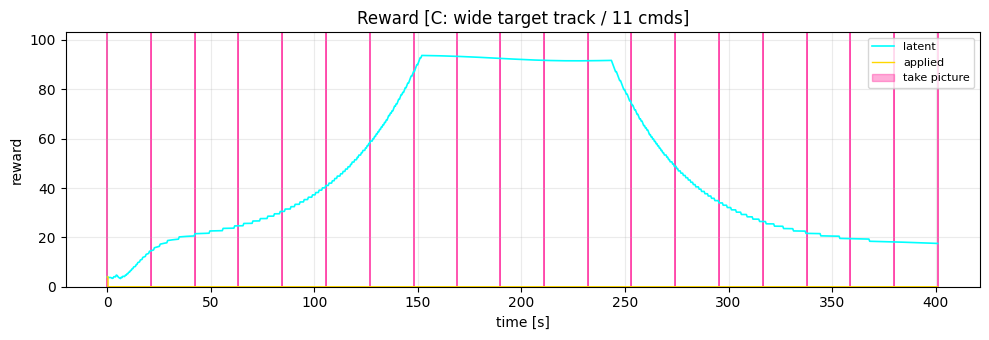

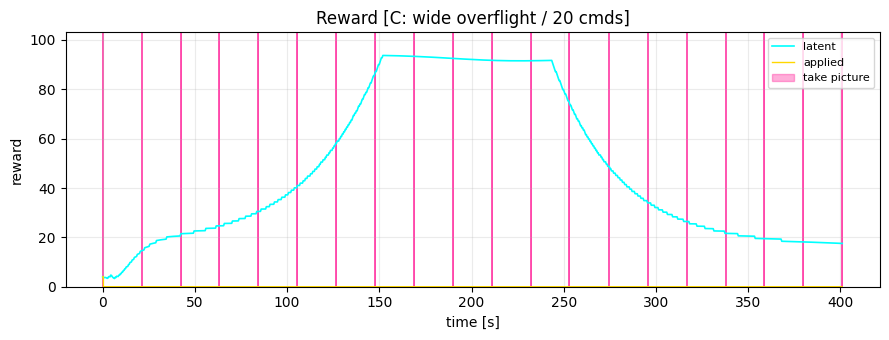

In [ ]:
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.5))
tpv.plot_capture_reward_timeline(
    ctx_c.series,
    cmd_steps=ctx_c.cmd_steps,
    label="C: wide overflight / 20 cmds",
    ax=ax,
)
plt.tight_layout()
plt.show()